# Modelos Fundacionales y Panorama Actual
**Objetivo del bloque**: construir el mapa completo del ecosistema actual de IA
y entender como el ciclo de desarrollo AI-first difiere del software tradicional.

El error de adopción mas comun: tratar un sistema con LLM como si fuera software determinista.
El comportamiento es emergente, no escrito. Eso cambia todo el ciclo de vida.

---

**Estructura del notebook:**
1. El stack de IA moderna - 5 capas del ecosistema
2. LLMs: que son y que los hace capaces
3. Tipos de tareas automatizables - cuando SQL basta y cuando no
4. Mapa de arquitecturas por tipo de dato
5. Mapa de proveedores y criterio de selección para la empresa
6. El ciclo AI-first vs ciclo de software tradicional

In [1]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


In [2]:
%pip install -q numpy matplotlib scikit-learn
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
print("[OK] Entorno listo.")

Note: you may need to restart the kernel to use updated packages.
[OK] Entorno listo.


---
## 1. El Stack de IA Moderna

La IA moderna se organiza en capas. Cada bloque del programa corresponde a una o varias:

```
CAPA 5 APLICACIONES DE NEGOCIO
       Copilotos, asistentes, automatizaciones, predicciones

CAPA 4 ORQUESTACIÓN Y AGENTES
       Pipelines, workflows, sistemas multi-agente, MCP

CAPA 3 PATRONES DE INTEGRACIÓN
       RAG, tool calling, embeddings, vector stores

CAPA 2 INTERACCIÓN CON MODELOS
       Prompting, salidas estructuradas, guardrails

CAPA 1 MODELOS FUNDACIONALES
       LLMs, modelos de embedding, modelos de difusión

CAPA 0 FUNDAMENTOS
       Machine Learning, redes neuronales, matemáticas
```

Los bloques 1-5 cubrieron la Capa 0-1. Este bloque mapea las Capas 1-5.
Los bloques 7-13 se sumergen en cada capa.

**El cambio epistemológico clave:**
En software clasico, el comportamiento es exactamente lo que el programador escribio.
En sistemas con modelos fundacionales, el comportamiento es **emergente**:
depende del modelo, del prompt, del contexto y de la distribución de casos reales.

Esto hace que la observación continua en producción sea tan importante como la construcción.

> **Antes de seguir:** ¿qué proceso de tu trabajo podría beneficiarse de la IA y por qué crees que todavía no se ha automatizado?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Una fricción real: falta de datos estructurados, coste de integración, resistencia organizativa, o simplemente que nadie ha priorizado el proyecto
- La distinción entre "podría beneficiarse" (valor) y "no se ha hecho" (barrera): son preguntas distintas
- La intuición de que la barrera más común no es técnica, sino de prioridad y formulación del problema

**Si nadie responde, preguntar:**
"¿Cuál es el proceso de la empresa donde una persona toma decisiones repetitivas basándose siempre en la misma información? ¿Qué impediría que un sistema lo hiciera?"

**Señal de comprensión:**
El alumno separa el análisis de valor (qué ganaría la empresa) del análisis de viabilidad (qué lo hace difícil). Si puede nombrar una barrera concreta más allá de "es complicado", ha empezado a pensar como un evaluador de proyectos de IA, no solo como un usuario.

</details>

---
## 2. Ciclo AI-first vs Ciclo de Software Tradicional

| Fase | Software tradicional | AI-first con LLMs |
|---|---|---|
| Inicio | Especificar comportamiento exacto | Experimentar con prompts y casos de prueba |
| Construcción | Implementar lógica determinista | Seleccionar modelo, diseñar prompt, evaluar |
| Despliegue | Desplegar versión estable | Desplegar con monitorización continua |
| Mantenimiento | Corregir bugs en el código | Ajustar datos, prompt o modelo al derivar |
| Calidad | Tests unitarios deterministas | Evaluación estadística sobre conjunto de test |
| Fallo | El sistema falla o no falla | El sistema degrada gradualmente |

**Para el equipo:**
El primer proyecto AI-first exitoso no es el que usa el modelo mas potente.
Es el que establece métricas de evaluación antes de escribir la primera línea de código
y las monitoriza sistemáticamente en producción.

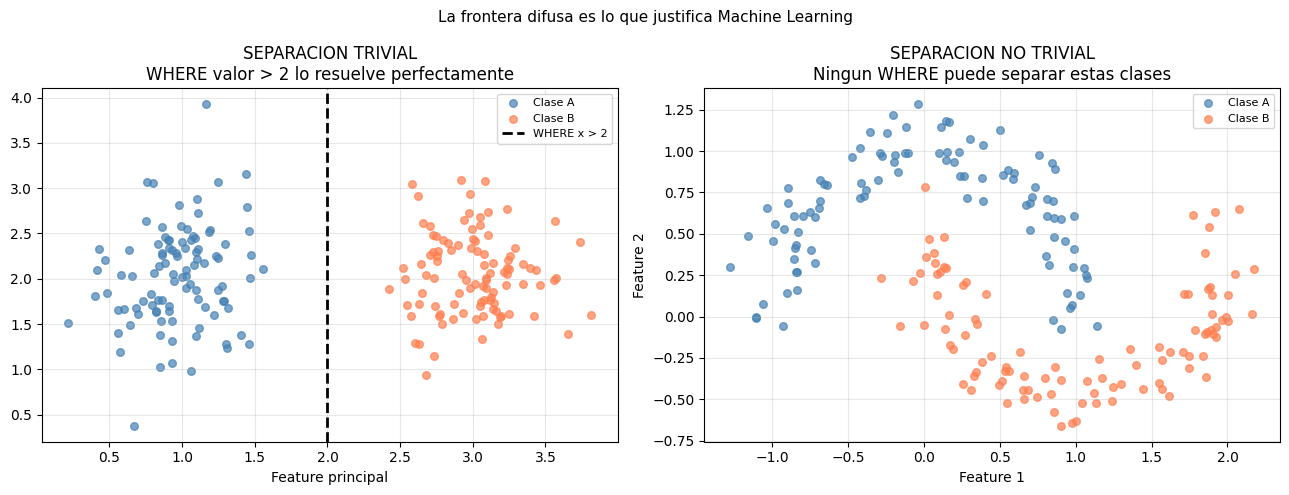

Panel izquierdo: un analista puede escribir la regla. No necesita ML.
Panel derecho: la frontera es curva, no existe ningun WHERE que la capture.
Churn de clientes, urgencia de tickets, riesgo de pedido: todos son como el panel derecho.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Visualizacion: cuando SQL basta y cuando no
np.random.seed(42)
n = 200

# Caso 1: separacion trivial (SQL WHERE funciona)
x1_a = np.random.normal(1, 0.3, n // 2)
x1_b = np.random.normal(3, 0.3, n // 2)
y1_a = np.random.normal(2, 0.5, n // 2)
y1_b = np.random.normal(2, 0.5, n // 2)

# Caso 2: separacion no trivial (necesita ML)
X_moons, y_moons = make_moons(n_samples=n, noise=0.12, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(x1_a, y1_a, c='steelblue', alpha=0.7, label='Clase A', s=30)
ax1.scatter(x1_b, y1_b, c='coral', alpha=0.7, label='Clase B', s=30)
ax1.axvline(x=2.0, color='black', linestyle='--', linewidth=2, label='WHERE x > 2')
ax1.set_title('SEPARACION TRIVIAL\nWHERE valor > 2 lo resuelve perfectamente')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Feature principal')

ax2.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1],
            c='steelblue', alpha=0.7, label='Clase A', s=30)
ax2.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1],
            c='coral', alpha=0.7, label='Clase B', s=30)
ax2.set_title('SEPARACION NO TRIVIAL\nNingun WHERE puede separar estas clases')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

plt.suptitle('La frontera difusa es lo que justifica Machine Learning', fontsize=11)
plt.tight_layout()
plt.savefig('images/B06_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Panel izquierdo: un analista puede escribir la regla. No necesita ML.")
print("Panel derecho: la frontera es curva, no existe ningun WHERE que la capture.")
print("Churn de clientes, urgencia de tickets, riesgo de pedido: todos son como el panel derecho.")

---
## 3. Tipos de Tareas Automatizables con IA

No todas las tareas se benefician igual de la IA.
La regla práctica para la empresa: empezar por las de mayor ROI y menor riesgo.

| Tipo de tarea | Ejemplo en la empresa | ROI | Riesgo |
|---|---|---|---|
| **Clasificar** | Clasificar tickets por tipo y prioridad | Alto | Bajo |
| **Extraer** | Extraer requisitos de una RFP | Alto | Bajo |
| **Resumir** | Resumir hilo de soporte de 30 mensajes | Alto | Bajo |
| **Buscar** | Buscar en documentación técnica con lenguaje natural | Alto | Bajo |
| **Generar** | Generar borradores de User Stories | Medio | Medio |
| **Razonar** | Diagnosticar causa raíz de un error en logs | Medio | Medio |
| **Colaborar** | Pipeline completo RFP a propuesta automatizada | Alto | Alto |

**Secuencia recomendada**: Clasificar/Extraer -> Buscar/Resumir -> Generar -> Razonar -> Colaborar

La diferencia entre RLE (resumen matemático perfecto) y LLM (resumen semántico):
```
Datos binarios:  0000000011111111110000011111
RLE:             7x0 10x1 5x0 5x1  <- perfecto, sin IA

Email de soporte con bloqueo de almacén + pedido urgente + referencias duplicadas:
RLE: no puede detectar la urgencia ni las referencias
LLM: extrae bloqueo, pedido en riesgo mañana, REF-4521 duplicada
```

---
## 4. LLMs: Que los Hace Capaces

Un LLM es un Transformer decoder-only entrenado con billones de tokens
para predecir el siguiente token.

**Parámetros clave:**
- **Número de parámetros**: 7B (modelos pequeños) a 100B+ (modelos grandes)
- **Context window**: cuantos tokens puede procesar a la vez (8K a 200K+)
- **Datos de entrenamiento**: calidad y diversidad del corpus

**Dos fases de entrenamiento:**
1. **Pre-entrenamiento**: predecir el siguiente token sobre billones de tokens.
   Produce un modelo base que completa texto pero no sigue instrucciones.
2. **Fine-tuning con instrucciones**: pares (instrucción, respuesta) curados.
   RLHF convierte el completador de texto en un asistente útil y seguro.

**Capacidades emergentes:**
Las capacidades no crecen gradualmente con el tamaño: aparecen abruptamente
al superar ciertos umbrales. Un modelo de 1B no puede razonar sobre matemáticas;
uno de 100B si, y además puede explicar el proceso.

**Implicación para la empresa:**
La elección del modelo importa.
Un modelo pequeño basta para clasificar tickets.
Analizar una RFP de 200 páginas requiere un modelo grande con context window amplio.

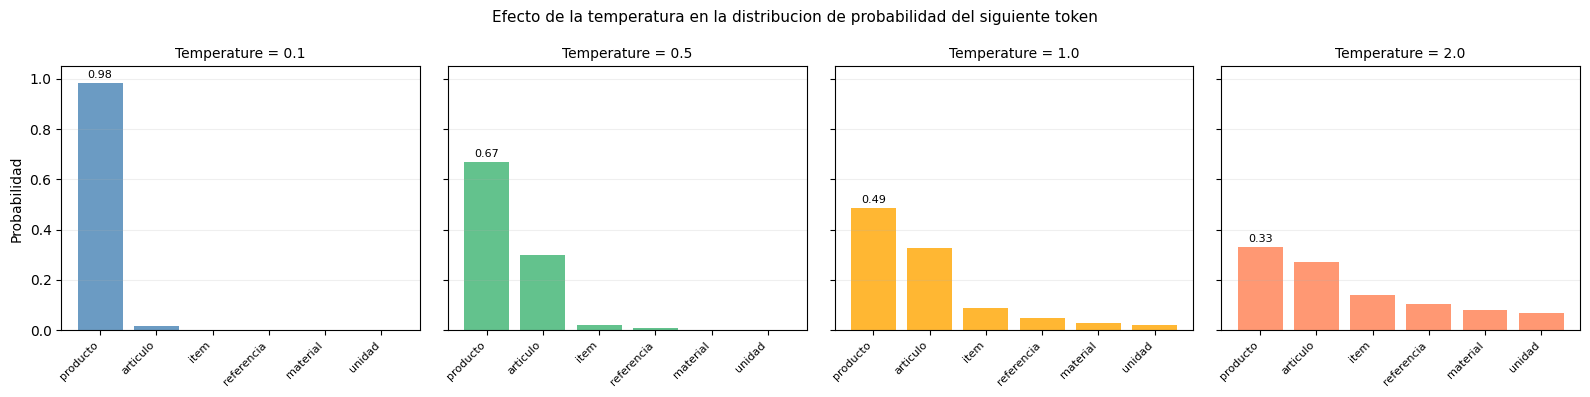

Temperature baja (0.1): el modelo es casi determinista. Siempre elige el token mas probable.
Temperature alta (2.0): la probabilidad se distribuye mas. Mayor variedad, menor coherencia.
Para la empresa en produccion: temperature baja (0.0-0.3) para clasificacion y extraccion.
Temperature media (0.5-0.8) para generacion de contenido.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizacion del efecto de la temperatura en la distribucion de probabilidad
# La temperatura controla la 'creatividad' vs 'determinismo' del modelo

# Logits de ejemplo para 6 tokens posibles
tokens = ['producto', 'articulo', 'item', 'referencia', 'material', 'unidad']
logits = np.array([3.2, 2.8, 1.5, 0.9, 0.4, 0.1])

temperaturas = [0.1, 0.5, 1.0, 2.0]
colores = ['steelblue', 'mediumseagreen', 'orange', 'coral']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, temp, color in zip(axes, temperaturas, colores):
    logits_scaled = logits / temp
    exp_logits = np.exp(logits_scaled - logits_scaled.max())
    probs = exp_logits / exp_logits.sum()

    bars = ax.bar(range(len(tokens)), probs, color=color, alpha=0.8)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Temperature = {temp}', fontsize=10)
    ax.set_ylim(0, 1.05)
    if temp == 0.1:
        ax.set_ylabel('Probabilidad')
    # Mostrar prob del token mas probable
    ax.text(0, probs[0] + 0.02, f'{probs[0]:.2f}', ha='center', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Efecto de la temperatura en la distribucion de probabilidad del siguiente token',
             fontsize=11)
plt.tight_layout()
plt.savefig('images/B06_fig02.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Temperature baja (0.1): el modelo es casi determinista. Siempre elige el token mas probable.")
print("Temperature alta (2.0): la probabilidad se distribuye mas. Mayor variedad, menor coherencia.")
print("Para la empresa en produccion: temperature baja (0.0-0.3) para clasificacion y extraccion.")
print("Temperature media (0.5-0.8) para generacion de contenido.")

---
## 5. Mapa de Arquitecturas y Proveedores

### Por tipo de dato

| Tipo de datos | Arquitectura recomendada | Caso de uso la empresa |
|---|---|---|
| Tabular (ERP, CRM) | Gradient Boosting (XGBoost) | Predicción de inventarios, churn |
| Texto (comprensión) | LLM via API (Claude, GPT) | Clasificación de tickets, sentimiento |
| Texto (generación) | LLM via API (Claude, GPT) | Respuestas a RFP, User Stories |
| Series temporales | LSTM o GB con features | Demanda, tendencias de uso |
| Imagen | Vision API o CNN | OCR de facturas, control de calidad |

### Tres preguntas antes de elegir arquitectura

1. **¿Hay suficientes datos etiquetados?**
   < 1000 ejemplos: LLM via API con few-shot. > 10K: entrenar clasificador propio.

2. **¿El conocimiento esta en datos históricos o en lenguaje?**
   Patrones en datos (churn, demanda): modelos tabulares.
   Conocimiento en documentos (manual de producto, FAQs): RAG sobre documentación.

3. **¿La salida necesita ser justificable ante un auditor?**
   Si: Gradient Boosting con SHAP values (interpretable).
   No: LLM (potente pero no inspectable directamente).

### Proveedores para la empresa

| Proveedor | Cuando usarlo |
|---|---|
| Claude (Anthropic) | Desarrollo y prototipado (razonamiento, context window 200K) |
| Azure OpenAI | Producción con compliance europeo (.NET, Azure nativo) |
| Llama (on-premise) | Casos con datos ultra-sensibles que no pueden salir de la empresa |
| Semantic Kernel | Framework .NET para integrar IA en el stack existente |
| N8N | Automatizaciones no críticas sin desarrollo de backend |

In [5]:
# Herramienta de decision rapida: arquitectura por tipo de dato y tarea

def elegir_arquitectura(tipo_dato, n_ejemplos_etiquetados, conocimiento_en, justificacion_requerida):
    """
    tipo_dato: 'tabular', 'texto', 'imagen', 'serie_temporal'
    n_ejemplos_etiquetados: numero de ejemplos etiquetados disponibles
    conocimiento_en: 'datos_historicos' o 'documentos'
    justificacion_requerida: True/False
    """
    print(f"Tipo de dato: {tipo_dato}")
    print(f"Ejemplos etiquetados: {n_ejemplos_etiquetados}")
    print(f"Conocimiento en: {conocimiento_en}")
    print(f"Justificacion requerida: {justificacion_requerida}")
    print("-" * 50)

    if tipo_dato == 'tabular':
        if justificacion_requerida:
            rec = "Gradient Boosting + SHAP values"
            just = "Interpretable: cada prediccion puede explicarse con contribucion de features"
        else:
            rec = "Gradient Boosting (XGBoost/LightGBM)"
            just = "Mejor rendimiento en datos tabulares con menos datos que redes neuronales"

    elif tipo_dato == 'texto':
        if conocimiento_en == 'documentos':
            rec = "RAG sobre base de conocimiento"
            just = "El conocimiento esta en documentos internos, no en patrones de comportamiento"
        elif n_ejemplos_etiquetados < 500:
            rec = "LLM via API (few-shot en el prompt)"
            just = f"Solo {n_ejemplos_etiquetados} ejemplos: insuficiente para entrenar, suficiente para few-shot"
        else:
            rec = "LLM via API o fine-tuning"
            just = "Con suficientes ejemplos, el fine-tuning puede superar el few-shot en precision"

    elif tipo_dato == 'imagen':
        rec = "Vision API (Claude Vision / Azure Computer Vision)"
        just = "Para imagenes de negocio, la API supera en velocidad y precision a entrenar CNN propia"

    elif tipo_dato == 'serie_temporal':
        if n_ejemplos_etiquetados < 1000:
            rec = "ARIMA / Prophet (estadistico clasico)"
            just = "Pocos datos historicos: modelos estadisticos son mas robustos"
        else:
            rec = "Gradient Boosting con lag features"
            just = "Con suficientes datos: GB con features temporales suele superar LSTM con menos complejidad"
    else:
        rec = "Definir mejor el problema"
        just = "El tipo de dato determina la arquitectura"

    print(f"Recomendacion: {rec}")
    print(f"Justificacion: {just}")
    print()

# Casos de la empresa
print("=" * 60)
print("DECISION DE ARQUITECTURA - CASOS EMPRESA")
print("=" * 60)
print()

elegir_arquitectura('tabular', 5000, 'datos_historicos', True)      # churn (requiere justificacion)
elegir_arquitectura('texto', 150, 'datos_historicos', False)        # clasificar tickets (pocos datos)
elegir_arquitectura('texto', 0, 'documentos', False)                # FAQ sobre producto
elegir_arquitectura('serie_temporal', 2000, 'datos_historicos', False)  # prediccion inventario
elegir_arquitectura('imagen', 500, 'datos_historicos', False)       # facturas escaneadas

DECISION DE ARQUITECTURA -  CASOS EMPRESA

Tipo de dato: tabular
Ejemplos etiquetados: 5000
Conocimiento en: datos_historicos
Justificacion requerida: True
--------------------------------------------------
Recomendacion: Gradient Boosting + SHAP values
Justificacion: Interpretable: cada prediccion puede explicarse con contribucion de features

Tipo de dato: texto
Ejemplos etiquetados: 150
Conocimiento en: datos_historicos
Justificacion requerida: False
--------------------------------------------------
Recomendacion: LLM via API (few-shot en el prompt)
Justificacion: Solo 150 ejemplos: insuficiente para entrenar, suficiente para few-shot

Tipo de dato: texto
Ejemplos etiquetados: 0
Conocimiento en: documentos
Justificacion requerida: False
--------------------------------------------------
Recomendacion: RAG sobre base de conocimiento
Justificacion: El conocimiento esta en documentos internos, no en patrones de comportamiento

Tipo de dato: serie_temporal
Ejemplos etiquetados: 2000
Co

---
## 7. Ejercicio de Decisión: ¿usarias IA aquí?

### Caso: asistente de soporte técnico sobre documentación de la empresa

El equipo de soporte de la empresa quiere un sistema que responda preguntas técnicas
sobre la configuración de la empresa sin que el agente tenga que buscar manualmente
en la documentación. Disponen de:
- 500 páginas de documentación técnica interna (actualizada cada 3 meses)
- 2 años de historial de tickets resueltos (pregunta + respuesta)

Un proveedor propone hacer fine-tuning de un LLM con toda esa información.

---

**Pregunta 1 - Fine-tuning vs RAG**
¿En que se diferencian fundamentalmente? Explica cada uno en 2-3 líneas.

**Pregunta 2 - Tu recomendación**
¿Cual de los dos usarias para este caso y por que?
Ten en cuenta que la documentación se actualiza cada 3 meses.

**Pregunta 3 - Los riesgos de cada enfoque**
¿Que riesgo específico tiene el fine-tuning en este caso?
¿Que riesgo específico tiene el RAG?

**Pregunta 4 - Cuando si tiene sentido el fine-tuning**
Describe un caso concreto (puede ser de la empresa o general) en que el fine-tuning
sea claramente mejor que el RAG.

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - Fine-tuning vs RAG:**

*(escribe aquí)*

**Pregunta 2 - Tu recomendación:**

*(escribe aquí)*

**Pregunta 3 - Los riesgos de cada enfoque:**

*(escribe aquí)*

**Pregunta 4 - Cuando si tiene sentido el fine-tuning:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - Fine-tuning vs RAG:
Fine-tuning: modificar los pesos del modelo con nuevos datos de entrenamiento.
El modelo "interioriza" el conocimiento pero lo congela en el momento del entrenamiento.
RAG: el modelo no cambia; en cada consulta se recuperan fragmentos relevantes de una base documental
y se incluyen en el contexto del prompt.
Insuficiente: confundir fine-tuning con preentrenamiento, o describir RAG como "búsqueda en Google".

Pregunta 2 - La recomendación:
Respuesta correcta para este caso: RAG.
Razón principal: la documentacion se actualiza cada 3 meses. Con fine-tuning, cada actualización
requiere un nuevo ciclo de entrenamiento (costoso). Con RAG, basta con reindexar los nuevos documentos.
El historial de tickets puede usarse como few-shot examples en el prompt, no requiere fine-tuning.
Insuficiente: recomendar RAG sin justificar el motivo de la actualización frecuente.

Pregunta 3 - Los riesgos:
Fine-tuning: conocimiento obsoleto (los pesos no se actualizan con nueva documentacion sin reentrenar),
overfitting a los ejemplos de entrenamiento, perdida de capacidades generales del modelo.
RAG: calidad de la recuperación (si el retriever no devuelve el fragmento correcto, la respuesta falla),
alucinaciones mezclando información de varios fragmentos, latencia mayor que un LLM directo.
Incompleto: mencionar solo riesgos de un enfoque.

Pregunta 4 - Cuando si tiene sentido el fine-tuning:
Casos validos:
 - Tono o estilo muy específico que debe seguir el modelo en todas las respuestas
 - Dominio con jerga técnica muy específica que el modelo base no entiende
 - Datos no estructurados que no se pueden recuperar facilmente como fragmentos
 - Casos donde la latencia de RAG es inaceptable y el conocimiento es estable
Incorrecto: proponer fine-tuning para documentacion que se actualiza frecuentemente.
-->


---
## Puntos clave del Bloque 6

1. **El ciclo AI-first es diferente**: el sistema degrada gradualmente en lugar de fallar bruscamente.
   La monitorización en producción es tan importante como la construcción.

2. **El stack tiene 5 capas**: cada capa tiene su propósito.
   No montar una capa superior si la inferior no esta consolidada.

3. **La arquitectura sigue al dato**: tabular -> GB, texto -> LLM, imagen -> API de visión.
   No existe la arquitectura universal.

4. **La temperature controla la creatividad**: temperature baja para precisión y consistencia,
   temperature alta para variedad. En producción, casi siempre temperature baja.

5. **Para la empresa**: Claude para prototipar, Azure OpenAI para producir con compliance,
   Llama para datos ultra-sensibles, Semantic Kernel para integración .NET.

---
**Siguiente bloque**: Prompting como Programación Declarativa - 
diseñar prompts como si fueran código: versionados, testeados, desplegados.